# SmolVLM Evaluation on PHLOP Dataset

Zero-shot and fine-tuned evaluation with physics properties ablation (with/without physical properties in the prompt).

In [1]:
!export PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True


!export HF_HOME=/workspace/huggingface
!export TRANSFORMERS_CACHE=/workspace/huggingface
!export TORCH_HOME=/workspace/huggingface
!export XDG_CACHE_HOME=/workspace/cache

In [1]:
import os

os.environ["HF_HOME"] = "/workspace/huggingface"
os.environ["TRANSFORMERS_CACHE"] = "/workspace/huggingface"
os.environ["TORCH_HOME"] = "/workspace/huggingface"
os.environ["XDG_CACHE_HOME"] = "/workspace/cache"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

print("HF_HOME:", os.environ["HF_HOME"])
print("XDG_CACHE_HOME:", os.environ["XDG_CACHE_HOME"])

HF_HOME: /workspace/huggingface
XDG_CACHE_HOME: /workspace/cache


In [2]:
!echo $XDG_CACHE_HOME
!echo $PYTORCH_CUDA_ALLOC_CONF

/workspace/cache
expandable_segments:True


In [3]:
!pip install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cu128 --force-reinstall

Looking in indexes: https://download.pytorch.org/whl/nightly/cu128

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


In [3]:
%pip install "transformers>=4.49.0" accelerate
%pip install peft bitsandbytes
%pip install datasets huggingface_hub
%pip install av Pillow matplotlib num2words
%pip install flash-attn --no-build-isolation
%pip install 'accelerate>=1.1.0'


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.2 -> 26.0.1
[noti

In [3]:
# from google.colab import drive
# drive.mount("/content/drive")

In [4]:
!python -c "import torch; print(torch.__version__)"
!python -c "import torchvision; print(torchvision.__version__)"

2.4.1+cu124
0.19.1+cu124


## Configuration

In [5]:
import os
import sys
from pathlib import Path
from huggingface_hub import login

os.environ["TOKENIZERS_PARALLELISM"] = "false"

sys.path.insert(0, str(Path(".").resolve()))

from phlop_eval_common import (
    load_phlop_splits, EVAL_OPTIONS,
    FINE_TUNE_CONFIGS, get_val_difficulty_filter,
)
from smol_eval import (
    run_zero_shot_smolvlm,
    # run_finetune_smolvlm,
    finetune_single_config,
    run_test_comparison_smolvlm,
    SMOLVLM_MODEL_ID,
    INFERENCE_BATCH_SIZE,
    NUM_VIDEO_FRAMES,
)

REPO_ID = "zimmari-ai/phlop"
HF_TOKEN = os.environ.get("HF_TOKEN", True)
MAX_SAMPLES = None  # None = evaluate all questions; set to e.g. 20 for quick testing
MAX_STEPS = 200
BATCH_SIZE = INFERENCE_BATCH_SIZE  # 16 on CUDA (A100), adjust if OOM
COMPILE_MODEL = True
VIDEO_FRAMES = NUM_VIDEO_FRAMES  # reduce to 4 for ~2x speed on MPS (some accuracy cost)

# DRIVE_RESULTS_DIR = "/content/drive/MyDrive/Uni/MS Project/results"
# DRIVE_RESULTS_DIR = "project/results"
DRIVE_RESULTS_DIR = "results"
OUTPUT_DIR = os.path.join(DRIVE_RESULTS_DIR, "models")

os.makedirs(DRIVE_RESULTS_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

import shutil

def sync_to_drive(local_path: str, drive_dir: str = DRIVE_RESULTS_DIR):
    """Copy a local file to Google Drive for persistence."""
    dst = os.path.join(drive_dir, os.path.basename(local_path))
    shutil.copy2(local_path, dst)
    print(f"  -> Drive: {dst}")

def sync_results_dir(local_dir: str = "results", drive_dir: str = DRIVE_RESULTS_DIR):
    """Copy all files from local results dir to Google Drive."""
    os.makedirs(drive_dir, exist_ok=True)
    for f in sorted(os.listdir(local_dir)):
        src = os.path.join(local_dir, f)
        if os.path.isfile(src):
            shutil.copy2(src, os.path.join(drive_dir, f))
    print(f"Synced {local_dir}/ -> {drive_dir}/")

In [9]:
HF_TOKEN = os.environ.get("HF_TOKEN", "")

In [10]:
if isinstance(HF_TOKEN, str) and HF_TOKEN.startswith("hf_"):
    login(token=HF_TOKEN)

## Load Dataset from HuggingFace

In [11]:
if "splits" not in dir() or not splits:
    splits = load_phlop_splits(REPO_ID, token=HF_TOKEN)
else:
    print("Dataset already loaded, skipping reload.")
for name, ds in splits.items():
    print(f"  {name}: {len(ds)} scenes")

Loading splits ['train', 'validation', 'test'] from zimmari-ai/phlop ...


Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/320 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

  train: 16000 scenes
  validation: 2000 scenes
  test: 2000 scenes
  train: 16000 scenes
  validation: 2000 scenes
  test: 2000 scenes


## Part 1: Zero-shot Evaluation

Evaluated on **test** split with **both static and moving** camera modes, with and without physical properties in the prompt.

In [5]:
import json

os.makedirs("results", exist_ok=True)

cam = "static"
use_physics = False
tag = "no_physics"

print(f"Zero-shot — camera: {cam}, physics: {tag}")
result = run_zero_shot_smolvlm(
    splits,
    camera_mode=cam,
    max_samples=MAX_SAMPLES,
    results_dir="results",
    eval_splits=["test"],
    compile_model=COMPILE_MODEL,
    batch_size=BATCH_SIZE,
    num_frames=VIDEO_FRAMES,
    use_physics=use_physics,
)

cam_path = f"results/smolvlm_zero_shot_metrics_{cam}_test_{tag}.json"
with open(cam_path, "w") as f:
    json.dump(result, f, indent=2, default=str)
sync_to_drive(cam_path)

pred_file = f"results/smolvlm_zero_shot_predictions_test_{cam}_{tag}.json"
if os.path.exists(pred_file):
    sync_to_drive(pred_file)
print(f"Done: {cam}/test/{tag}")

Zero-shot — camera: static, split: validation


`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

Using device: mps (dtype=torch.float16)
  Building eval index (camera=static)...


Indexing eval scenes: 100%|█████████████████████████████████████████████████████████████████████████████| 2000/2000 [00:34<00:00, 57.95it/s]


  Eval index: 25436 (scene, question) pairs from 2000 scenes

--- Zero-shot on validation (static): 25436 questions (evaluating 25436) ---


A decoder-only architecture is being used, but right-padding was detected! For correct generation results, please set `padding_side='left'` when initializing the tokenizer.


KeyboardInterrupt: 

In [ ]:
cam = "static"
use_physics = True
tag = "with_physics"

print(f"Zero-shot — camera: {cam}, physics: {tag}")
result = run_zero_shot_smolvlm(
    splits,
    camera_mode=cam,
    max_samples=MAX_SAMPLES,
    results_dir="results",
    eval_splits=["test"],
    compile_model=COMPILE_MODEL,
    batch_size=BATCH_SIZE,
    num_frames=VIDEO_FRAMES,
    use_physics=use_physics,
)

cam_path = f"results/smolvlm_zero_shot_metrics_{cam}_test_{tag}.json"
with open(cam_path, "w") as f:
    json.dump(result, f, indent=2, default=str)
sync_to_drive(cam_path)

pred_file = f"results/smolvlm_zero_shot_predictions_test_{cam}_{tag}.json"
if os.path.exists(pred_file):
    sync_to_drive(pred_file)
print(f"Done: {cam}/test/{tag}")

In [ ]:
cam = "moving"
use_physics = False
tag = "no_physics"

print(f"Zero-shot — camera: {cam}, physics: {tag}")
result = run_zero_shot_smolvlm(
    splits,
    camera_mode=cam,
    max_samples=MAX_SAMPLES,
    results_dir="results",
    eval_splits=["test"],
    compile_model=COMPILE_MODEL,
    batch_size=BATCH_SIZE,
    num_frames=VIDEO_FRAMES,
    use_physics=use_physics,
)

cam_path = f"results/smolvlm_zero_shot_metrics_{cam}_test_{tag}.json"
with open(cam_path, "w") as f:
    json.dump(result, f, indent=2, default=str)
sync_to_drive(cam_path)

pred_file = f"results/smolvlm_zero_shot_predictions_test_{cam}_{tag}.json"
if os.path.exists(pred_file):
    sync_to_drive(pred_file)
print(f"Done: {cam}/test/{tag}")

In [ ]:
cam = "moving"
use_physics = True
tag = "with_physics"

print(f"Zero-shot — camera: {cam}, physics: {tag}")
result = run_zero_shot_smolvlm(
    splits,
    camera_mode=cam,
    max_samples=MAX_SAMPLES,
    results_dir="results",
    eval_splits=["test"],
    compile_model=COMPILE_MODEL,
    batch_size=BATCH_SIZE,
    num_frames=VIDEO_FRAMES,
    use_physics=use_physics,
)

cam_path = f"results/smolvlm_zero_shot_metrics_{cam}_test_{tag}.json"
with open(cam_path, "w") as f:
    json.dump(result, f, indent=2, default=str)
sync_to_drive(cam_path)

pred_file = f"results/smolvlm_zero_shot_predictions_test_{cam}_{tag}.json"
if os.path.exists(pred_file):
    sync_to_drive(pred_file)
print(f"Done: {cam}/test/{tag}")

In [ ]:
camera_modes = ["static", "moving"]
physics_tags = ["no_physics", "with_physics"]

zero_shot_results = {}
for cam in camera_modes:
    zero_shot_results[cam] = {}
    for tag in physics_tags:
        path = os.path.join(DRIVE_RESULTS_DIR, f"smolvlm_zero_shot_metrics_{cam}_test_{tag}.json")
        if os.path.exists(path):
            with open(path) as f:
                data = json.load(f)
            zero_shot_results[cam][tag] = data

merged_path = os.path.join(DRIVE_RESULTS_DIR, "smolvlm_zero_shot_metrics.json")
with open(merged_path, "w") as f:
    json.dump(zero_shot_results, f, indent=2, default=str)
print(f"Merged zero-shot metrics into {merged_path}")

### Zero-shot Visualizations

Grouped bar charts showing metrics across splits and camera modes, plus accuracy breakdown by question type.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

zs_data = zero_shot_results

groups = []
group_labels = []
for cam in camera_modes:
    for tag in physics_tags:
        entry = zs_data.get(cam, {}).get(tag, {}).get("test", {})
        m = entry.get("metrics", entry)
        groups.append(m.get("answer_accuracy", 0))
        group_labels.append(f"{cam}/{tag}")

x = np.arange(len(group_labels))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(x, groups)
ax.set_xticks(x)
ax.set_xticklabels(group_labels, rotation=15, ha="right")
ax.set_ylabel("Answer Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Zero-shot Answer Accuracy: Physics Props Ablation (test)")
for bar, val in zip(bars, groups):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
chart_path = os.path.join(DRIVE_RESULTS_DIR, "chart_zero_shot_metrics_overview.png")
plt.savefig(chart_path, dpi=150)
plt.show()

fig, axes = plt.subplots(1, len(camera_modes), figsize=(7 * len(camera_modes), 6), sharey=True)
if len(camera_modes) == 1:
    axes = [axes]
for ax, cam in zip(axes, camera_modes):
    entry = zs_data.get(cam, {}).get("no_physics", {}).get("test", {})
    m = entry.get("metrics", entry)
    pqt = m.get("per_question_type", {})
    if not pqt:
        ax.set_title(f"{cam} — no per-type data")
        continue
    sorted_types = sorted(pqt.items(), key=lambda kv: -kv[1]["count"])
    names = [t for t, _ in sorted_types]
    accs = [v["accuracy"] for _, v in sorted_types]
    counts = [v["count"] for _, v in sorted_types]
    y = np.arange(len(names))
    bars = ax.barh(y, accs)
    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Accuracy")
    ax.set_title(f"Zero-shot Accuracy by Question Type ({cam})")
    for bar, c in zip(bars, counts):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"n={c}", va="center", fontsize=7)
plt.tight_layout()
chart_path = os.path.join(DRIVE_RESULTS_DIR, "chart_zero_shot_accuracy_by_question_type.png")
plt.savefig(chart_path, dpi=150)
plt.show()

In [ ]:
plot_cams = ["static"]  # add "moving" here to get 4 bars per question type

conditions = []
for cam in plot_cams:
    for tag in physics_tags:
        conditions.append((cam, tag))

all_qtypes: dict[str, dict[tuple, dict]] = {}
for cam, tag in conditions:
    entry = zs_data.get(cam, {}).get(tag, {}).get("test", {})
    m = entry.get("metrics", entry)
    pqt = m.get("per_question_type", {})
    for qt, vals in pqt.items():
        all_qtypes.setdefault(qt, {})[( cam, tag)] = vals

sorted_qtypes = sorted(all_qtypes.keys(), key=lambda qt: -max(
    v.get("count", 0) for v in all_qtypes[qt].values()
))

y = np.arange(len(sorted_qtypes))
bar_h = 0.8 / len(conditions)
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, max(5, len(sorted_qtypes) * 0.55)))

for i, (cam, tag) in enumerate(conditions):
    accs = []
    counts = []
    for qt in sorted_qtypes:
        vals = all_qtypes.get(qt, {}).get((cam, tag), {})
        accs.append(vals.get("accuracy", 0))
        counts.append(vals.get("count", 0))
    offsets = y + i * bar_h - (len(conditions) - 1) * bar_h / 2
    bars = ax.barh(offsets, accs, height=bar_h, label=f"{cam} / {tag}",
                   color=colors[i % len(colors)])
    for bar, c in zip(bars, counts):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"n={c}", va="center", fontsize=6)

ax.set_yticks(y)
ax.set_yticklabels(sorted_qtypes, fontsize=8)
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_title("Zero-shot Accuracy by Question Type (test)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
chart_path = os.path.join(DRIVE_RESULTS_DIR, "chart_zero_shot_per_qtype_grouped.png")
plt.savefig(chart_path, dpi=150)
plt.show()

## Part 2: Fine-tuning

Four difficulty configurations x 2 physics modes (with/without physical properties in prompt):
1. **easy** — train on easy questions, validate on medium/hard/very_hard
2. **easy_medium** — train on easy+medium, validate on hard/very_hard
3. **hard** — train on hard questions, validate on easy/medium/very_hard
4. **full** — train on all questions

In [10]:
# Clear stale shard cache (one-time, before re-running training)
import shutil, os
cache = os.path.expanduser("/workspace/cache/phlop_shards")
if os.path.exists(cache):
    shutil.rmtree(cache)
    print(f"Cleared {cache}")

Cleared /workspace/cache/phlop_shards


In [13]:
OUTPUT_DIR

'results/models'

In [12]:
FINE_TUNE_CONFIGS

{'easy': {'train_difficulty': ['easy'], 'val_on_rest': True},
 'easy_medium': {'train_difficulty': ['easy', 'medium'], 'val_on_rest': True},
 'hard': {'train_difficulty': ['hard'], 'val_on_rest': True},
 'full': {'train_difficulty': None, 'val_on_rest': False}}

In [14]:
import shutil, os

os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_EPOCHS = 1          
EARLY_STOPPING_PATIENCE = 3
EVAL_STEPS = 100 # evaluate every 100 steps for responsive early stopping

print("Fine-tuning configurations:")
for name, cfg in FINE_TUNE_CONFIGS.items():
    val_diff = get_val_difficulty_filter(cfg["train_difficulty"])
    print(f"  {name}: train={cfg['train_difficulty']}, val={val_diff}")
print(f"\nModels will be saved to: {OUTPUT_DIR}/")

all_saved_dirs = {}
for cfg_name in FINE_TUNE_CONFIGS:
    cfg_name = "hard"
    # for use_physics in [False, True]:
    for use_physics in [False]:
        # clean up
        cache = os.path.expanduser("~/.cache/phlop_shards")
        if os.path.exists(cache):
            shutil.rmtree(cache)
            print(f"Cleared {cache}")
                
        tag = "with_physics" if use_physics else "no_physics"
        print(f"\n{'#'*60}")
        print(f"Config: {cfg_name} | physics={use_physics} ({tag})")
        print(f"{'#'*60}")
        ckpt = finetune_single_config(
            splits,
            cfg_name=cfg_name,
            output_dir=OUTPUT_DIR,
            # max_steps=MAX_STEPS,
            eval_steps=EVAL_STEPS,
            num_epochs=NUM_EPOCHS,
            early_stopping_patience=EARLY_STOPPING_PATIENCE,
            camera_mode="static",
            use_physics=use_physics,
        )
        if ckpt:
            all_saved_dirs[f"smolvlm_{cfg_name}_{tag}"] = ckpt
            print(f"\nSaved: {ckpt}")
        break

print(f"\nAll saved checkpoints: {all_saved_dirs}")
print(f"\nModels directory contents:")
for f in sorted(os.listdir(OUTPUT_DIR)):
    print(f"  {OUTPUT_DIR}/{f}")

Fine-tuning configurations:
  easy: train=['easy'], val=['medium', 'hard', 'very_hard']
  easy_medium: train=['easy', 'medium'], val=['hard', 'very_hard']
  hard: train=['hard'], val=['easy', 'medium', 'very_hard']
  full: train=None, val=None

Models will be saved to: results/models/

############################################################
Config: hard | physics=False (no_physics)
############################################################

Fine-tuning config: hard (no_physics)
  Train difficulties: ['hard'], Val difficulties: ['easy', 'medium', 'very_hard']
  Building training index (camera=static, difficulty=['hard'])...
  Loaded cached index: 19164 pairs from /cache/phlop_shards/index_cache/idx_16000_static_hard_nofb.json
  Training index: 19164 (scene, question) pairs
  Building training index (camera=static, difficulty=['easy', 'medium', 'very_hard'])...
  Loaded cached index: 21321 pairs from /cache/phlop_shards/index_cache/idx_2000_static_easy_medium_very_hard_nofb.json
 

`torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/657 [00:00<?, ?it/s]

/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:230: UserWarning: 
NVIDIA RTX PRO 4500 Blackwell with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA RTX PRO 4500 Blackwell GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


trainable params: 9,277,440 || all params: 2,256,062,320 || trainable%: 0.4112
  Training: 1 epoch(s), eval every 100 steps, early stopping patience=3


/usr/local/lib/python3.11/dist-packages/torch/cuda/__init__.py:230: UserWarning: 
NVIDIA RTX PRO 4500 Blackwell with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_50 sm_60 sm_70 sm_75 sm_80 sm_86 sm_90.
If you want to use the NVIDIA RTX PRO 4500 Blackwell GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(
You have used fast image processor with LANCZOS resample which not yet supported for torch.Tensor. BICUBIC resample will be used as an alternative. Please fall back to image processor if you want full consistency with the original model.


RuntimeError: CUDA error: no kernel image is available for execution on the device
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.


In [10]:
"test"

'test'

In [9]:
OUTPUT_DIR

'results/models'

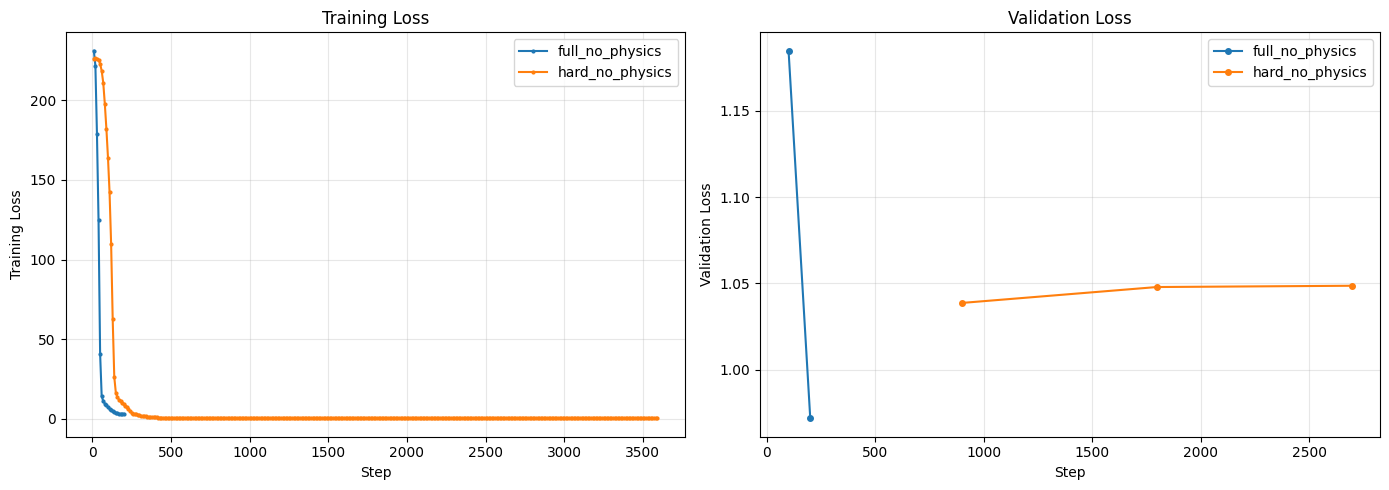

In [10]:
import json, os, glob
import matplotlib.pyplot as plt

model_dirs = sorted(
    d for d in os.listdir(OUTPUT_DIR)
    if os.path.isdir(os.path.join(OUTPUT_DIR, d))
)

fig, (ax_train, ax_val) = plt.subplots(1, 2, figsize=(14, 5))

for run_name in model_dirs:
    run_dir = os.path.join(OUTPUT_DIR, run_name)
    ckpt_dirs = sorted(
        [d for d in os.listdir(run_dir) if d.startswith("checkpoint-")],
        key=lambda d: int(d.split("-")[-1]),
    )
    state_path = (
        os.path.join(run_dir, ckpt_dirs[-1], "trainer_state.json")
        if ckpt_dirs
        else os.path.join(run_dir, "trainer_state.json")
    )
    if not os.path.exists(state_path):
        print(f"  No trainer state for {run_name}, skipping")
        continue

    with open(state_path) as f:
        state = json.load(f)
    log_history = state.get("log_history", [])

    train_steps = [e["step"] for e in log_history if "loss" in e]
    train_loss = [e["loss"] for e in log_history if "loss" in e]
    if train_steps:
        ax_train.plot(train_steps, train_loss, marker=".", markersize=4, label=run_name)

    eval_steps = [e["step"] for e in log_history if "eval_loss" in e]
    eval_loss = [e["eval_loss"] for e in log_history if "eval_loss" in e]
    if eval_steps:
        ax_val.plot(eval_steps, eval_loss, marker="o", markersize=4, label=run_name)

ax_train.set_xlabel("Step")
ax_train.set_ylabel("Training Loss")
ax_train.set_title("Training Loss")
ax_train.legend()
ax_train.grid(True, alpha=0.3)

ax_val.set_xlabel("Step")
ax_val.set_ylabel("Validation Loss")
ax_val.set_title("Validation Loss")
ax_val.legend()
ax_val.grid(True, alpha=0.3)

if not model_dirs:
    ax_train.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax_train.transAxes)
    ax_val.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax_val.transAxes)

plt.tight_layout()
chart_path = os.path.join(DRIVE_RESULTS_DIR, "chart_finetune_loss_curves.png")
plt.savefig(chart_path, dpi=150)
plt.show()

## Part 3: Test Comparison

Compare base model vs all fine-tuned checkpoints on the **test** split only, with matching physics mode (models trained with physics are evaluated with physics, and vice versa).

In [ ]:
cam = "static"

all_comparison_data = {}
for use_physics in [False, True]:
    tag = "with_physics" if use_physics else "no_physics"

    model_checkpoints = [("base", SMOLVLM_MODEL_ID)]
    for config_name in FINE_TUNE_CONFIGS:
        run_dir = os.path.join(OUTPUT_DIR, f"smolvlm_{config_name}_{tag}")
        if not os.path.isdir(run_dir):
            continue
        ckpt_dirs = sorted(
            [d for d in os.listdir(run_dir) if d.startswith("checkpoint-")],
            key=lambda d: int(d.split("-")[-1]),
        )
        ckpt = os.path.join(run_dir, ckpt_dirs[-1]) if ckpt_dirs else run_dir
        model_checkpoints.append((f"smolvlm_{config_name}_{tag}", ckpt))

    print(f"\nComparing {len(model_checkpoints)} models — camera: {cam}, physics: {tag}")
    table = run_test_comparison_smolvlm(
        splits,
        model_checkpoints,
        camera_mode=cam,
        results_dir="results",
        use_physics=use_physics,
    )

    cam_data = {name: split_metrics for name, split_metrics in table}
    all_comparison_data[tag] = cam_data

cam_path = f"results/smolvlm_finetuned_metrics_{cam}.json"
with open(cam_path, "w") as f:
    json.dump({cam: all_comparison_data}, f, indent=2, default=str)
sync_to_drive(cam_path)

for fname in os.listdir("results"):
    if fname.startswith("smolvlm_finetuned_predictions_") and cam in fname:
        sync_to_drive(f"results/{fname}")
print(f"Done: comparison for camera={cam}")

In [ ]:
cam = "moving"

all_comparison_data = {}
for use_physics in [False, True]:
    tag = "with_physics" if use_physics else "no_physics"

    model_checkpoints = [("base", SMOLVLM_MODEL_ID)]
    for config_name in FINE_TUNE_CONFIGS:
        run_dir = os.path.join(OUTPUT_DIR, f"smolvlm_{config_name}_{tag}")
        if not os.path.isdir(run_dir):
            continue
        ckpt_dirs = sorted(
            [d for d in os.listdir(run_dir) if d.startswith("checkpoint-")],
            key=lambda d: int(d.split("-")[-1]),
        )
        ckpt = os.path.join(run_dir, ckpt_dirs[-1]) if ckpt_dirs else run_dir
        model_checkpoints.append((f"smolvlm_{config_name}_{tag}", ckpt))

    print(f"\nComparing {len(model_checkpoints)} models — camera: {cam}, physics: {tag}")
    table = run_test_comparison_smolvlm(
        splits,
        model_checkpoints,
        camera_mode=cam,
        results_dir="results",
        use_physics=use_physics,
    )

    cam_data = {name: split_metrics for name, split_metrics in table}
    all_comparison_data[tag] = cam_data

cam_path = f"results/smolvlm_finetuned_metrics_{cam}.json"
with open(cam_path, "w") as f:
    json.dump({cam: all_comparison_data}, f, indent=2, default=str)
sync_to_drive(cam_path)

for fname in os.listdir("results"):
    if fname.startswith("smolvlm_finetuned_predictions_") and cam in fname:
        sync_to_drive(f"results/{fname}")
print(f"Done: comparison for camera={cam}")

In [ ]:
all_comparisons = {}
for cam in camera_modes:
    path = os.path.join(DRIVE_RESULTS_DIR, f"smolvlm_finetuned_metrics_{cam}.json")
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        all_comparisons[cam] = data.get(cam, {})

merged_path = os.path.join(DRIVE_RESULTS_DIR, "smolvlm_finetuned_metrics.json")
with open(merged_path, "w") as f:
    json.dump(all_comparisons, f, indent=2, default=str)
print(f"Merged finetuned metrics into {merged_path}")

### Test Comparison Visualizations

Bar charts comparing base model vs fine-tuned checkpoints on the test split.

In [ ]:
cmp_path = os.path.join(DRIVE_RESULTS_DIR, "smolvlm_finetuned_metrics.json")
with open(cmp_path) as f:
    cmp_data = json.load(f)

# --- Chart 1: Overview — Answer Accuracy per model/physics (like zero-shot overview) ---
groups = []
group_labels = []
for cam in camera_modes:
    for tag in physics_tags:
        tag_data = cmp_data.get(cam, {}).get(tag, {})
        for model_name in tag_data:
            m = tag_data[model_name].get("test", {})
            groups.append(m.get("answer_accuracy", 0))
            group_labels.append(f"{model_name}\n{cam}/{tag}")

x = np.arange(len(group_labels))

fig, ax = plt.subplots(figsize=(max(10, len(group_labels) * 1.2), 5))
bars = ax.bar(x, groups)
ax.set_xticks(x)
ax.set_xticklabels(group_labels, rotation=15, ha="right", fontsize=8)
ax.set_ylabel("Answer Accuracy")
ax.set_ylim(0, 1)
ax.set_title("Fine-tuned Test Accuracy: All Models × Physics Ablation")
for bar, val in zip(bars, groups):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.3f}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
chart_path = os.path.join(DRIVE_RESULTS_DIR, "chart_finetuned_answer_accuracy.png")
plt.savefig(chart_path, dpi=150)
plt.show()

# --- Chart 2: Accuracy by Question Type (horizontal bars, like zero-shot per-type) ---
fig, axes = plt.subplots(1, len(camera_modes), figsize=(7 * len(camera_modes), 6), sharey=True)
if len(camera_modes) == 1:
    axes = [axes]
for ax, cam in zip(axes, camera_modes):
    tag_data = cmp_data.get(cam, {}).get("no_physics", {})
    best_model = None
    best_acc = -1
    for name, metrics in tag_data.items():
        if name == "base":
            continue
        acc = metrics.get("test", {}).get("answer_accuracy", 0)
        if acc > best_acc:
            best_acc = acc
            best_model = name
    show_model = best_model or "base"
    m = tag_data.get(show_model, {}).get("test", {})
    pqt = m.get("per_question_type", {})
    if not pqt:
        ax.set_title(f"{cam} ({show_model}) — no per-type data")
        continue
    sorted_types = sorted(pqt.items(), key=lambda kv: -kv[1]["count"])
    names = [t for t, _ in sorted_types]
    accs = [v["accuracy"] for _, v in sorted_types]
    counts = [v["count"] for _, v in sorted_types]
    y = np.arange(len(names))
    bars = ax.barh(y, accs)
    ax.set_yticks(y)
    ax.set_yticklabels(names, fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_xlabel("Accuracy")
    ax.set_title(f"Fine-tuned Accuracy by Question Type ({cam}, {show_model})")
    for bar, c in zip(bars, counts):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                f"n={c}", va="center", fontsize=7)
plt.tight_layout()
chart_path = os.path.join(DRIVE_RESULTS_DIR, "chart_finetuned_accuracy_by_question_type.png")
plt.savefig(chart_path, dpi=150)
plt.show()

# --- Chart 3: Grouped by Question Type — base vs finetuned (like zero-shot grouped) ---
plot_cams = ["static"]

conditions = []
for cam in plot_cams:
    tag_data = cmp_data.get(cam, {}).get("no_physics", {})
    for model_name in tag_data:
        conditions.append((cam, "no_physics", model_name))

all_qtypes: dict[str, dict[tuple, dict]] = {}
for cam, tag, model_name in conditions:
    m = cmp_data.get(cam, {}).get(tag, {}).get(model_name, {}).get("test", {})
    pqt = m.get("per_question_type", {})
    for qt, vals in pqt.items():
        all_qtypes.setdefault(qt, {})[(cam, model_name)] = vals

sorted_qtypes = sorted(all_qtypes.keys(), key=lambda qt: -max(
    v.get("count", 0) for v in all_qtypes[qt].values()
))

y = np.arange(len(sorted_qtypes))
bar_h = 0.8 / max(len(conditions), 1)
colors = plt.cm.tab10.colors

fig, ax = plt.subplots(figsize=(12, max(5, len(sorted_qtypes) * 0.55)))

for i, (cam, tag, model_name) in enumerate(conditions):
    accs = []
    counts = []
    for qt in sorted_qtypes:
        vals = all_qtypes.get(qt, {}).get((cam, model_name), {})
        accs.append(vals.get("accuracy", 0))
        counts.append(vals.get("count", 0))
    offsets = y + i * bar_h - (len(conditions) - 1) * bar_h / 2
    bars = ax.barh(offsets, accs, height=bar_h, label=model_name,
                   color=colors[i % len(colors)])
    for bar, c in zip(bars, counts):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
                f"n={c}", va="center", fontsize=6)

ax.set_yticks(y)
ax.set_yticklabels(sorted_qtypes, fontsize=8)
ax.set_xlim(0, 1)
ax.set_xlabel("Accuracy")
ax.set_title("Fine-tuned Accuracy by Question Type — Base vs Fine-tuned (test)")
ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
chart_path = os.path.join(DRIVE_RESULTS_DIR, "chart_finetuned_per_qtype_grouped.png")
plt.savefig(chart_path, dpi=150)
plt.show()

## Results Summary

In [ ]:
import csv

zs_path = os.path.join(DRIVE_RESULTS_DIR, "smolvlm_zero_shot_metrics.json")
with open(zs_path) as f:
    zs_summary = json.load(f)

cmp_path = os.path.join(DRIVE_RESULTS_DIR, "smolvlm_finetuned_metrics.json")
cmp_summary = {}
if os.path.exists(cmp_path):
    with open(cmp_path) as f:
        cmp_summary = json.load(f)

print("=" * 60)
print("  ZERO-SHOT RESULTS (test only)")
print("=" * 60)
for cam in camera_modes:
    for tag in physics_tags:
        entry = zs_summary.get(cam, {}).get(tag, {}).get("test", {})
        m = entry.get("metrics", entry)
        n = entry.get("n_questions", "?")
        print(f"\n  Camera: {cam} | Physics: {tag} | Questions: {n}")
        print(f"    answer_accuracy:          {m.get('answer_accuracy', 0):.4f}")

print(f"\n{'=' * 60}")
print("  FINE-TUNED MODEL COMPARISON (test only)")
print("=" * 60)
for cam in camera_modes:
    for tag in physics_tags:
        tag_data = cmp_summary.get(cam, {}).get(tag, {})
        if not tag_data:
            continue
        print(f"\n--- Camera: {cam} | Physics: {tag} ---")
        print(f"{'Model':<30} {'AnswerAcc':>10}")
        print("-" * 45)
        for model_name, split_metrics in tag_data.items():
            m = split_metrics.get("test", {})
            if m:
                print(f"{model_name:<30} {m.get('answer_accuracy', 0):>10.4f}")

csv_path = os.path.join(DRIVE_RESULTS_DIR, "smolvlm_all_metrics_summary.csv")
with open(csv_path, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow(["phase", "camera", "split", "use_physics", "model", "answer_accuracy"])
    for cam in camera_modes:
        for tag in physics_tags:
            entry = zs_summary.get(cam, {}).get(tag, {}).get("test", {})
            m = entry.get("metrics", entry)
            writer.writerow(["zero_shot", cam, "test", tag, "SmolVLM2-2.2B",
                             f"{m.get('answer_accuracy', 0):.4f}"])
    for cam in camera_modes:
        for tag in physics_tags:
            tag_data = cmp_summary.get(cam, {}).get(tag, {})
            for model_name, split_metrics in tag_data.items():
                for split_name, m in split_metrics.items():
                    writer.writerow(["fine_tuned", cam, split_name, tag, model_name,
                                     f"{m.get('answer_accuracy', 0):.4f}"])
print(f"\nSaved: {csv_path}")

print(f"\nAll saved artifacts:")
print(f"  Models:  {OUTPUT_DIR}/<easy|easy_medium|hard|full>/")
print(f"  Results: {DRIVE_RESULTS_DIR}/")
print(f"\nFiles in {DRIVE_RESULTS_DIR}/:")
for f in sorted(os.listdir(DRIVE_RESULTS_DIR)):
    print(f"    {f}")

### Full Predictions Table

Export a single CSV with every prediction across all configurations: video path, question, options, difficulty, true answer, model prediction, camera mode, split, and model name.

In [ ]:
import glob

columns = [
    "phase", "model", "camera_mode", "split", "use_physics",
    "scene_idx", "qa_idx", "video_path",
    "question", "options", "difficulty", "question_type",
    "true_answer", "prediction",
    "prompt",
]

all_rows = []

for pred_file in sorted(glob.glob("results/smolvlm_zero_shot_predictions_*.json")):
    with open(pred_file) as f:
        preds = json.load(f)
    for r in preds:
        all_rows.append({
            "phase": "zero_shot",
            "model": "SmolVLM2-2.2B",
            "camera_mode": r.get("camera_mode", ""),
            "split": r.get("split", ""),
            "use_physics": str(r.get("use_physics", False)),
            "scene_idx": r.get("scene_idx", ""),
            "qa_idx": r.get("qa_idx", ""),
            "video_path": r.get("video_path", ""),
            "question": r.get("question", ""),
            "options": str(r.get("options", "")),
            "difficulty": r.get("difficulty", ""),
            "question_type": r.get("question_type", ""),
            "true_answer": r.get("true_answer", r.get("answer", "")),
            "prediction": r.get("prediction", ""),
            "prompt": r.get("prompt", ""),
        })

for pred_file in sorted(glob.glob("results/smolvlm_finetuned_predictions_*.json")):
    with open(pred_file) as f:
        preds = json.load(f)
    for r in preds:
        all_rows.append({
            "phase": "fine_tuned",
            "model": r.get("model", os.path.basename(pred_file).split("_")[3]),
            "camera_mode": r.get("camera_mode", ""),
            "split": r.get("split", ""),
            "use_physics": str(r.get("use_physics", False)),
            "scene_idx": r.get("scene_idx", ""),
            "qa_idx": r.get("qa_idx", ""),
            "video_path": r.get("video_path", ""),
            "question": r.get("question", ""),
            "options": str(r.get("options", "")),
            "difficulty": r.get("difficulty", ""),
            "question_type": r.get("question_type", ""),
            "true_answer": r.get("true_answer", r.get("answer", "")),
            "prediction": r.get("prediction", ""),
            "prompt": r.get("prompt", ""),
        })

out_path = "results/smolvlm_full_predictions_table.csv"
with open(out_path, "w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=columns)
    writer.writeheader()
    writer.writerows(all_rows)

print(f"Saved {len(all_rows)} predictions to {out_path}")
print(f"  Columns: {columns}")

# Show breakdown
from collections import Counter
breakdown = Counter((r["phase"], r["model"], r["camera_mode"], r["split"]) for r in all_rows)
print(f"\nBreakdown:")
print(f"  {'Phase':<12} {'Model':<20} {'Camera':<10} {'Split':<12} {'Count':>6}")
print(f"  {'-'*65}")
for (phase, model, cam, split), count in sorted(breakdown.items()):
    print(f"  {phase:<12} {model:<20} {cam:<10} {split:<12} {count:>6}")

sync_to_drive(out_path)